<a href="https://colab.research.google.com/github/sbhoora/YoYo/blob/main/YoYo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import networkx as nx
import matplotlib.pyplot as plt

def yoyo(DAG):
  yoyo_DAG = DAG.copy()

  msg_complexity = 0

  while len(yoyo_DAG.nodes()) > 1:

    for node_id in list(yoyo_DAG.nodes()):
      yoyo_DAG.nodes[node_id]['msg_r'] = []
      yoyo_DAG.nodes[node_id]['yes'] = []
      yoyo_DAG.nodes[node_id]['no'] = []

    edges_to_flip = []
    edges_to_remove = []

    sources = [node for node in yoyo_DAG.nodes() if yoyo_DAG.in_degree(node) == 0 and yoyo_DAG.out_degree(node) > 0]
    sinks = [node for node in yoyo_DAG.nodes() if yoyo_DAG.out_degree(node) == 0 and yoyo_DAG.in_degree(node) > 0]
    internal_nodes = [node for node in yoyo_DAG.nodes() if yoyo_DAG.in_degree(node) > 0 and yoyo_DAG.out_degree(node) > 0]

    nodes_to_remove_this_round = []

    # DOWNSTREAM - source nodes
    queue = []
    for source_node in sources:
      for _, v, key in yoyo_DAG.out_edges(source_node, keys=True):
        msg_complexity += 1
        yoyo_DAG.nodes[v]['msg_r'].append(source_node)
        if len(yoyo_DAG.nodes[v]['msg_r']) == yoyo_DAG.in_degree(v):
          queue.append(v)

    # DOWNSTREAM - internal nodes
    while queue:
      internal_node = queue.pop(0)
      min_val = min(yoyo_DAG.nodes[internal_node]['msg_r'])

      if len(yoyo_DAG.nodes[internal_node]['msg_r']) == yoyo_DAG.in_degree(internal_node):
        for _, v, key in yoyo_DAG.out_edges(internal_node, keys=True):
          msg_complexity += 1
          yoyo_DAG.nodes[v]['msg_r'].append(min_val)
          if len(yoyo_DAG.nodes[v]['msg_r']) == yoyo_DAG.in_degree(v):
            queue.append(v)

    # UPSTREAM - sink nodes
    upstream = []
    while sinks:
      sink_node = sinks.pop(0)
      source_sent_yes = 0

      if len(yoyo_DAG.nodes[sink_node]['msg_r']) == yoyo_DAG.in_degree(sink_node):
        min_val = min(yoyo_DAG.nodes[sink_node]['msg_r'])
        for u, _, key in yoyo_DAG.in_edges(sink_node, keys=True):
          msg_complexity += 1
          if min_val in yoyo_DAG.nodes[u]['msg_r'] or u == min_val:
            if source_sent_yes > 0:
              edges_to_remove.append((u, sink_node))
            yoyo_DAG.nodes[u]['yes'].append(min_val)
            source_sent_yes += 1
          else:
            yoyo_DAG.nodes[u]['no'].append(sink_node)
            edges_to_flip.append((u, sink_node))

          if (len(yoyo_DAG.nodes[u]['yes'])+len(yoyo_DAG.nodes[u]['no'])) == yoyo_DAG.out_degree(u):
            upstream.append(u)
        if yoyo_DAG.in_degree(sink_node) == 1:
          nodes_to_remove_this_round.append(sink_node)
      else:
        print(sink_node, 'UH-OH', yoyo_DAG.nodes[sink_node]['msg_r'] )
        break

    # UPSTREAM - internal nodes
    sent_yes = 0
    while upstream:
      internal_node = upstream.pop(0)

      if (len(yoyo_DAG.nodes[internal_node]['yes'])+len(yoyo_DAG.nodes[internal_node]['no'])) == yoyo_DAG.out_degree(internal_node):
        min_list = yoyo_DAG.nodes[internal_node]['yes']
        min_val = min(min_list, default=math.inf)
        no_count = len(yoyo_DAG.nodes[internal_node]['no'])

        for u, _, key in yoyo_DAG.in_edges(internal_node, keys=True):
          msg_complexity += 1

          if no_count == 0 and min_val != math.inf and (min_val in yoyo_DAG.nodes[u]['msg_r'] or u == min_val):
            if sent_yes > 0:
              edges_to_remove.append((u, internal_node))

            yoyo_DAG.nodes[u]['yes'].append(min_val)
            sent_yes += 1
          else:
            yoyo_DAG.nodes[u]['no'].append(internal_node)
            edges_to_flip.append((u, internal_node))

          if (len(yoyo_DAG.nodes[u]['yes'])+len(yoyo_DAG.nodes[u]['no'])) == yoyo_DAG.out_degree(u):
            upstream.append(u)
        sent_yes=0

    # Remove collected nodes
    for node_id in nodes_to_remove_this_round:
      if yoyo_DAG.has_node(node_id):
        yoyo_DAG.remove_node(node_id)

    # Remove redundant YES edges
    for u, v in edges_to_remove:
      if yoyo_DAG.has_node(u) and yoyo_DAG.has_node(v) and yoyo_DAG.has_edge(u, v):
        yoyo_DAG.remove_edge(u, v)

    # Apply edge flips
    for u, v in edges_to_flip:
      if yoyo_DAG.has_node(u) and yoyo_DAG.has_node(v) and yoyo_DAG.has_edge(u, v):
        edge_keys = list(yoyo_DAG[u][v].keys())
        if edge_keys:
          key_to_remove = edge_keys[0]
          yoyo_DAG.remove_edge(u, v, key=key_to_remove)
          yoyo_DAG.add_edge(v, u)

    if len(yoyo_DAG.nodes()) == 1:
      # # FOR TESTING UNCOMMENT THE PLT LINES BELOW TO SEE FINAL GRAPH
      # plt.figure(figsize=(6, 6))
      # pos = nx.spring_layout(yoyo_DAG)
      # nx.draw(yoyo_DAG, pos, with_labels=True, node_color='lightgreen', node_size=800, font_size=14)
      # plt.title(f"Final Graph: {len(yoyo_DAG.nodes())}")
      # plt.show()
      return msg_complexity

In [ ]:
import networkx as nx
import random

def create_graph(n, m):
  G = nx.Graph()
  G.add_nodes_from(range(n))

  nodes = list(range(n))
  random.shuffle(nodes)

  # create a random spanning tree
  for i in range(1, n):
    u = nodes[i]
    v = random.choice(nodes[:i])
    G.add_edge(u, v)

  # add edges until the required number of edges is met
  edges_m = m - G.number_of_edges()

  if edges_m > 0:
    edges_in_graph = set()
    for u, v in G.edges():
      # track what edges are currently in the graph, while ensuring low --> high
      edges_in_graph.add(tuple(sorted((u, v))))

    # generate a list of potential edges that could be added
    edge_options = []
    for u in range(n):
      for v in range(u + 1, n):
        if (u, v) not in edges_in_graph:
          edge_options.append((u, v))

    # randomly select edges from list of potential edges, and add them
    # until required number of edges is met
    edges_m = min(edges_m, len(edge_options))
    if edges_m > 0:
      chosen_edges = random.sample(edge_options, edges_m)
      for u, v in chosen_edges:
        G.add_edge(u, v)

  # take the connections from the undirected graph and add them to a directed
  # graph while ensuring that edges point from low value node to high value
  D = nx.MultiDiGraph()
  for u, v in G.edges():
    if u < v:
      D.add_edge(u, v)
    else:
      D.add_edge(v, u)

  return D

##Fix n and vary m (Impact of Graph Density)

In [ ]:
import matplotlib.pyplot as plt
import math
import multiprocessing
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def process_batch(batch_tasks):
  results = []
  for n, m in batch_tasks:
    G = create_graph(n, m)
    results.append(yoyo(G))
  return results

nm_values = []
for n in [20,30,40,60,80,100]:
  m_values = [
    n,
    int(n*math.log(n)),
    int(n*math.sqrt(n)),
    n*n
  ]
  for m in m_values:
    # ensure m doesn't exceed the max number of edges a graph can have
    max_m = n * (n - 1) // 2
    m = min(m, max_m)
    nm_values.extend([(n, m)] * 1000)

batch_size = 10
batches = [nm_values[i:i + batch_size] for i in range(0, len(nm_values), batch_size)]

results = []
with ProcessPoolExecutor(max_workers=None) as executor:
  futures = [executor.submit(process_batch, batch) for batch in batches]

  for future in tqdm(futures, total=len(batches), desc="Generating graphs (in batches of 10)"):
    results.extend(future.result())

stats = defaultdict(list)
for (n, m), vals in zip(nm_values, results):
  stats[(n, m)].append(vals)

print("\nResults:")
for (n, m), vals in stats.items():
  avg = sum(vals) / len(vals)
  print(f"\n n={n}, m={m}, runs={len(vals)}, avg msg={avg:.2f}")

Generating graphs (in batches of 10): 100%|██████████| 2400/2400 [07:07<00:00,  5.61it/s]



Results:

 n=20, m=20, runs=1000, avg msg=120.23

 n=20, m=59, runs=1000, avg msg=233.82

 n=20, m=89, runs=1000, avg msg=273.68

 n=20, m=190, runs=1000, avg msg=418.00

 n=30, m=30, runs=1000, avg msg=187.36

 n=30, m=102, runs=1000, avg msg=402.20

 n=30, m=164, runs=1000, avg msg=495.99

 n=30, m=435, runs=1000, avg msg=928.00

 n=40, m=40, runs=1000, avg msg=252.80

 n=40, m=147, runs=1000, avg msg=581.28

 n=40, m=252, runs=1000, avg msg=749.13

 n=40, m=780, runs=1000, avg msg=1638.00

 n=60, m=60, runs=1000, avg msg=381.71

 n=60, m=245, runs=1000, avg msg=965.33

 n=60, m=464, runs=1000, avg msg=1328.09

 n=60, m=1770, runs=1000, avg msg=3658.00

 n=80, m=80, runs=1000, avg msg=505.17

 n=80, m=350, runs=1000, avg msg=1374.32

 n=80, m=715, runs=1000, avg msg=2003.87

 n=80, m=3160, runs=1000, avg msg=6478.00

 n=100, m=100, runs=1000, avg msg=637.98

 n=100, m=460, runs=1000, avg msg=1806.41

 n=100, m=1000, runs=1000, avg msg=2763.52

 n=100, m=4950, runs=1000, avg msg=1009

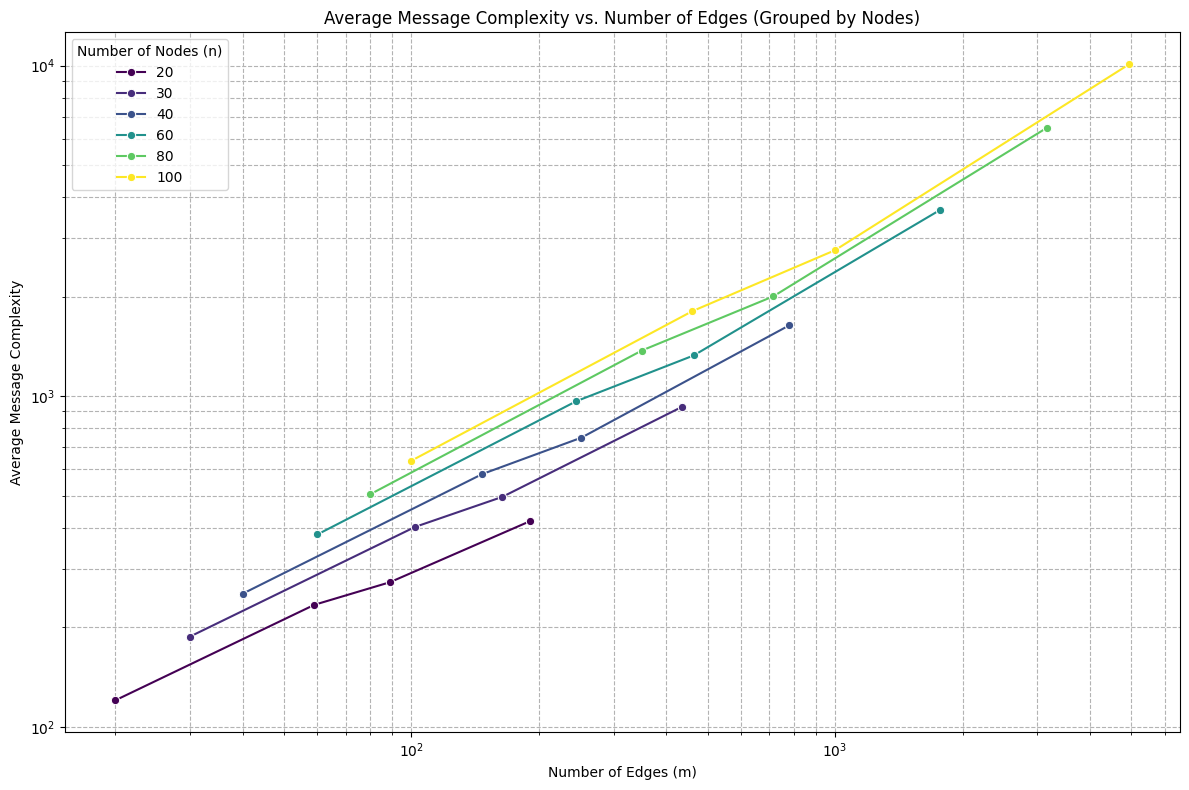

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
for (n, m), vals in stats.items():
  avg = sum(vals) / len(vals)
  plot_data.append({'n': n, 'm': m, 'msg_comp': avg})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_plot, x='m', y='msg_comp', hue='n', marker='o', palette='viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Average Message Complexity vs. Number of Edges (Grouped by Nodes)')
plt.xlabel('Number of Edges (m)')
plt.ylabel('Average Message Complexity')
plt.grid(True, which='both', ls='--', c='0.7')
plt.legend(title='Number of Nodes (n)')
plt.tight_layout()
plt.show()

##Fix m and vary n (Impact of Graph Size)

In [ ]:
import matplotlib.pyplot as plt
import math
import multiprocessing
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def process_batch(batch_tasks):
  results = []
  for n, m in batch_tasks:
    G = create_graph(n, m)
    results.append(yoyo(G))
  return results

nm_values = []
for n in [20,30,40,60,80,100]:
  nm_values.extend([(n, 2*n)] * 1000)

batch_size = 10
batches = [nm_values[i:i + batch_size] for i in range(0, len(nm_values), batch_size)]

results = []
with ProcessPoolExecutor(max_workers=None) as executor:
  futures = [executor.submit(process_batch, batch) for batch in batches]

  for future in tqdm(futures, total=len(batches), desc="Generating graphs (in batches of 10)"):
    results.extend(future.result())

stats = defaultdict(list)
for (n, m), vals in zip(nm_values, results):
  stats[(n, m)].append(vals)

print("\nResults:")
for (n, m), vals in stats.items():
  avg = sum(vals) / len(vals)
  print(f"\n n={n}, m={m}, runs={len(vals)}, avg msg={avg:.2f}")

Generating graphs (in batches of 10): 100%|██████████| 600/600 [00:44<00:00, 13.35it/s]


Results:

 n=20, m=40, runs=1000, avg msg=200.74

 n=30, m=60, runs=1000, avg msg=322.53

 n=40, m=80, runs=1000, avg msg=446.84

 n=60, m=120, runs=1000, avg msg=700.13

 n=80, m=160, runs=1000, avg msg=957.33

 n=100, m=200, runs=1000, avg msg=1217.83


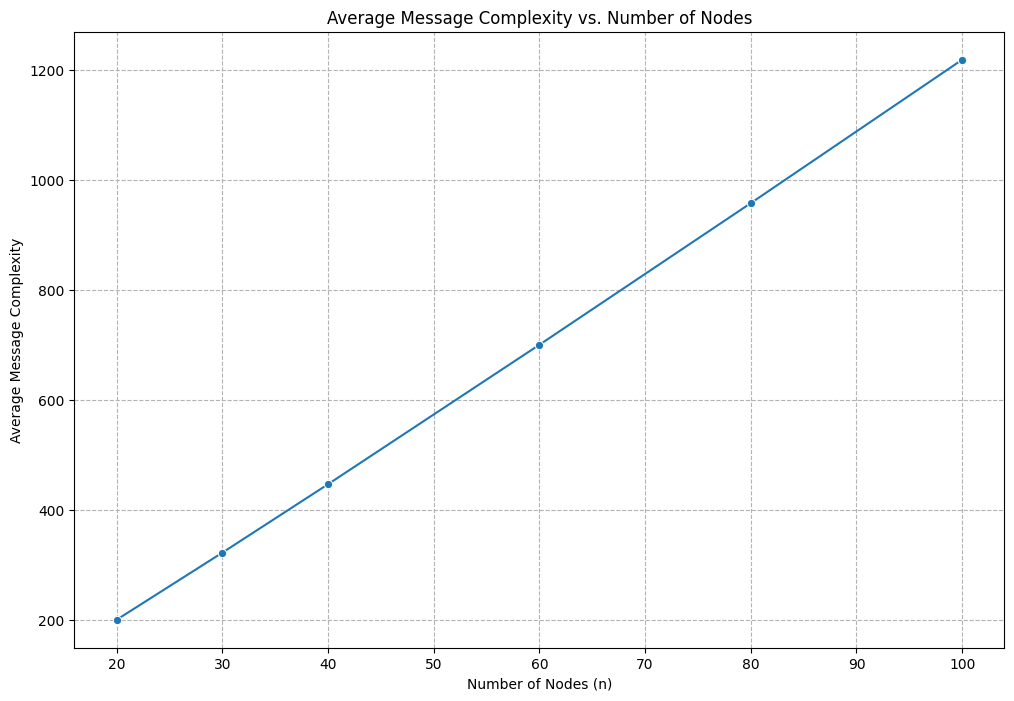

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
for (n, m), vals in stats.items():
  avg = sum(vals) / len(vals)
  plot_data.append({'n': n, '2n': m, 'msg_comp': avg})

df_plot = pd.DataFrame(plot_data)

plt.figure(figsize=(12, 8))
sns.lineplot(data=df_plot, x='n', y='msg_comp', marker='o')
plt.title('Average Message Complexity vs. Number of Nodes')
plt.xlabel('Number of Nodes (n)')
plt.ylabel('Average Message Complexity')
plt.grid(True, which='both', ls='--', c='0.7')
plt.show()